# 🎨 Part 1: PixArt-Sigma Ink-Wash LoRA — Data Preparation, Feature Caching & 20-Step Style Teacher Training & Evaluation
### *Complete Master Guide: Dataset Scraping, Automated VLM Captioning, SDXL VAE Latent Precomputation, T5-XXL Text Conditioning, 20-Step Style Teacher LoRA Training, Provenance Manifest Validation, and Step 0 Baseline vs. Teacher Evaluation*

---

### 📌 Notebook Overview
This notebook covers the complete first half of the PixArt-Sigma efficient fine-tuning workflow:
1. **Environment Diagnostics & Prerequisites**: Validating CUDA hardware, memory limits, and the `pixart311` conda environment.
2. **Stage 0: Data Acquisition & Preprocessing**:
   - Web scraping raw Chinese ink-wash paintings into category directories (`plant/`, `animal/`, `landscape/`).
   - Automated VLM captioning with Florence-2 / JoyCaption with domain trigger phrases (`traditional Chinese ink wash painting style, shuimo hua`).
   - Precomputing 512px SDXL VAE clean latents ($4 	imes 64 	imes 64$, FP16) to eliminate training VAE encoding bottlenecks.
   - Precomputing T5-XXL text prompt embeddings (300 tokens, 4096 dim, FP16).
3. **Stage 1: 20-Step Style Teacher Training**:
   - Fine-tuning frozen PixArt-Sigma XL-2 512 DiT backbone with **LoRA Rank 16, Alpha 16** across 12 linear projection modules for 10,000 steps.
   - Real-time training progress tracking: step speed (iters/sec, step time), MSE loss convergence, learning rate schedule, VRAM monitoring.
4. **Stage 1.5: Teacher Provenance Contract Validation**:
   - Structural validation of the trained LoRA adapter (574 FP32 tensors, 13,765,376 adapter parameters).
   - Normalized manifest generation (`teacher_manifest.json`).
5. **Stage 1.6: Teacher Model vs. Step 0 Baseline Quality Evaluation**:
   - Text-image alignment (**CLIPScore**) and real image distribution distance (**CMMD**).
   - Step 0 Baseline vs Checkpoint visual comparison grids (0k, 1k, 3k, 5k, 7k, 10k steps).


## 0. 🛠️ Environment Diagnostics & Prerequisites
Activate the `pixart311` conda environment and verify CUDA hardware, VRAM, and dependencies.


In [1]:
import os
import sys
import gc
import json
import time
import math
import csv
import statistics
import hashlib
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Locate Repository Root
def get_repo_root() -> Path:
    curr = Path.cwd().resolve()
    for parent in [curr] + list(curr.parents):
        if (parent / "README.md").is_file() and (parent / "scripts").is_dir():
            return parent
    return curr

REPO_ROOT = get_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(f"[*] Repository Root: {REPO_ROOT}")
print(f"[*] Python Version:  {sys.version.split()[0]}")
print(f"[*] PyTorch Version: {torch.__version__}")
print(f"[*] CUDA Available:  {torch.cuda.is_available()}")

if torch.cuda.is_available():
    device_name = torch.cuda.get_device_name(0)
    vram_gb = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f"[*] GPU Device:      {device_name} ({vram_gb:.2f} GB VRAM)")
else:
    print("[!] No CUDA GPU detected. Distillation & LoRA training requires a GPU with >= 8GB VRAM.")


[*] Repository Root: C:\dev\efficient-pixart-sigma-lora
[*] Python Version:  3.11.15
[*] PyTorch Version: 2.5.1+cu121
[*] CUDA Available:  True
[*] GPU Device:      NVIDIA GeForce RTX 4070 (11.99 GB VRAM)


## 1. 📂 Stage 0: Data Acquisition & Preprocessing
If starting from scratch:
- Scrape raw images: `scripts/data/download_tappu.py`
- Run automated VLM captioning: `scripts/data/auto_caption.py --model florence-2 --trigger "traditional Chinese ink wash painting style, shuimo hua"`
- Inspect existing raw archives and manifest records.


In [2]:
raw_archive = REPO_ROOT / "data" / "archives" / "ink.zip"
legacy_archive = REPO_ROOT / "data" / "ink_legacy.zip"

print("[*] Inspecting Raw Dataset Archives...")
target_raw = raw_archive if raw_archive.is_file() else legacy_archive
print(f"   * Archive File: {target_raw.name} -> Exists: {target_raw.is_file()}")

if target_raw.is_file():
    import zipfile
    with zipfile.ZipFile(target_raw, "r") as zf:
        file_list = zf.namelist()
        img_files = [f for f in file_list if f.endswith(('.png', '.jpg', '.jpeg'))]
        txt_files = [f for f in file_list if f.endswith('.txt')]
        print(f"   [+] Total Archive Files: {len(file_list):,}")
        print(f"   [+] Image Files Found:   {len(img_files):,}")
        print(f"   [+] Caption Text Files:  {len(txt_files):,}")
        
        # Display sample caption
        if txt_files:
            sample_caption = zf.read(txt_files[0]).decode('utf-8', errors='ignore')
            print(f"   [+] Sample Caption ({txt_files[0]}):\n       {sample_caption.strip()}")


[*] Inspecting Raw Dataset Archives...
   * Archive File: ink_legacy.zip -> Exists: True
   [+] Total Archive Files: 502
   [+] Image Files Found:   249
   [+] Caption Text Files:  249
   [+] Sample Caption (ink/animal/100.txt):
       I drew a black cat kept in the studio using only ink. There is no painting subject that suits ink better than black cats and crows. The bleeding is used to give the hair a soft feel.


## 2. ⚡ Stage 0.2: Precomputed Feature Caching (Clean Latents & T5 Embeddings)
To accelerate training by over $10	imes$, we precompute:
1. **Clean Latents**: SDXL VAE ($4 	imes 64 	imes 64$, FP16) saved in `data/archives/clean_latents_512.zip`.
2. **T5-XXL Embeddings**: 300 tokens, 4096-dim FP16 embeddings saved in `data/features/t5_embeddings_*.pt`.


In [3]:
from scripts.distillation.common import (
    TRANSFORMER_MODEL,
    COMPONENT_MODEL,
    MANIFEST_FINGERPRINT,
    sha256_file
)
from scripts.training.train_local_latent_lora import load_latent_bundle

latent_archive = REPO_ROOT / "data" / "archives" / "clean_latents_512.zip"
t5_cache_file = REPO_ROOT / "data" / "features" / f"t5_embeddings_n260_len300_fp16_{MANIFEST_FINGERPRINT}.pt"

print("[*] Validating Precomputed Feature Caches...")
print(f"   * Clean Latents: {latent_archive.name} -> Exists: {latent_archive.is_file()}")
print(f"   * T5 Embeddings: {t5_cache_file.name} -> Exists: {t5_cache_file.is_file()}")

if latent_archive.is_file():
    latents, manifests = load_latent_bundle(latent_archive, plant_only=True)
    sample_key = next(iter(latents))
    print(f"   [+] Plant Clean Latents: {len(latents)} loaded | Shape: {tuple(latents[sample_key].shape)} | Dtype: {latents[sample_key].dtype}")

if t5_cache_file.is_file():
    t5_data = torch.load(t5_cache_file, map_location="cpu", weights_only=True)
    print(f"   [+] T5-XXL Embeddings:   {t5_data['prompt_embeds'].shape} | Attention Masks: {t5_data['attention_masks'].shape}")


[*] Validating Precomputed Feature Caches...
   * Clean Latents: clean_latents_512.zip -> Exists: False
   * T5 Embeddings: t5_embeddings_n260_len300_fp16_b9d3c2d1d404.pt -> Exists: True
   [+] T5-XXL Embeddings:   torch.Size([260, 300, 4096]) | Attention Masks: torch.Size([260, 300])


## 3. 🎓 Stage 1: 20-Step Style Teacher LoRA Training
Train the Style Teacher adapter on the 209-image plant subset for 10,000 steps using the frozen **PixArt-Sigma XL-2 512** DiT model.

### Training Configuration:
- **LoRA Rank ($r$)**: 16, **Alpha**: 16
- **Target Modules**: 12 linear projections (`to_q`, `to_k`, `to_v`, `to_out.0`, `linear_1`, `linear_2`, `ff.net.0.proj`, `ff.net.2`, `proj_in`, `proj_out`, `linear`, `proj`)
- **Optimizer**: AdamW ($LR = 1	imes 10^{-5}$)
- **Checkpoints**: Every 1,000 steps up to 10,000 steps


In [4]:
teacher_output_dir = REPO_ROOT / "outputs" / "style_teacher" / "plant_n209_steps10200" / "r16_lr1e-05"
print(f"[*] Target Teacher Output Directory: {teacher_output_dir}")

# Check for existing training logs / checkpoints
checkpoints = sorted(teacher_output_dir.glob("checkpoint-*")) if teacher_output_dir.exists() else []
print(f"[*] Existing Checkpoints Found: {len(checkpoints)}")
for cp in checkpoints[:5]:
    print(f"   * {cp.name}")


[*] Target Teacher Output Directory: C:\dev\efficient-pixart-sigma-lora\outputs\style_teacher\plant_n209_steps10200\r16_lr1e-05
[*] Existing Checkpoints Found: 0


## 4. 🔍 Stage 1.5: Validate Teacher Provenance & Manifest Contract
Structural validation confirms the adapter meets the exact mathematical specifications:
- Exact **574 FP32 tensors**
- Exact **13,765,376 parameters**
- Generates `teacher_manifest.json` required by distillation stages.


In [5]:
from scripts.distillation.validate_style_teacher_impl import inspect_adapter

teammate_adapter_path = REPO_ROOT / "outputs" / "style_teacher" / "best_ink_wash_lora_plant209_step4000"
active_teacher = teacher_output_dir if teacher_output_dir.exists() else teammate_adapter_path
teacher_id = "plant_n209_r16_step10200" if active_teacher == teacher_output_dir else "teammate_plant209_step4000"

print(f"[*] Active Style Teacher: '{teacher_id}' at {active_teacher}")

if active_teacher.exists():
    inspection = inspect_adapter(active_teacher)
    print(f"\n[+] Validated Teacher Adapter Structure:")
    print(f"   * Rank:                 {inspection['rank']}")
    print(f"   * LoRA Alpha:           {inspection['lora_alpha']}")
    print(f"   * Tensor Count:         {inspection['tensor_count']} (Expected: 574)")
    print(f"   * Adapter Parameters:   {inspection['parameter_count']:,} (Expected: 13,765,376)")
    print(f"   * Dtypes:               {inspection['dtypes']}")
    print(f"   * SHA256 (Weights):     {inspection['adapter_sha256'][:16]}...")
else:
    print("[!] Teacher adapter path not found on disk.")


[*] Active Style Teacher: 'teammate_plant209_step4000' at C:\dev\efficient-pixart-sigma-lora\outputs\style_teacher\best_ink_wash_lora_plant209_step4000
[!] Teacher adapter path not found on disk.


## 5. 📊 Stage 1.6: Teacher Quality Evaluation vs. Step 0 Baseline
Comparison of text-image alignment (**CLIPScore**) and ink-wash distribution quality across training checkpoints (0 to 10,000 steps).


[*] 10k Checkpoint Evaluation Table:


,dataset,num_images,rank,step,guidance_scale,clip_score,latency_sec,image_path
0,baseline,0,0,0,1.5,0.383973,22.0600,outputs\experiment_10k\eval_generations\baseli...
12,n100,100,16,1000,1.5,0.392452,17.1765,outputs\experiment_10k\eval_generations\n100\s...
13,n100,100,16,2000,1.5,0.385233,17.5934,outputs\experiment_10k\eval_generations\n100\s...
14,n100,100,16,3000,1.5,0.380116,17.4879,outputs\experiment_10k\eval_generations\n100\s...
15,n100,100,16,4000,1.5,0.379197,17.3727,outputs\experiment_10k\eval_generations\n100\s...
16,n100,100,16,5000,1.5,0.376884,17.0113,outputs\experiment_10k\eval_generations\n100\s...
17,n100,100,16,6000,1.5,0.376843,17.7862,outputs\experiment_10k\eval_generations\n100\s...
18,n100,100,16,7000,1.5,0.371397,18.4390,outputs\experiment_10k\eval_generations\n100\s...
19,n100,100,16,8000,1.5,0.350971,17.7064,outputs\experiment_10k\eval_generations\n100\s...
20,n100,100,16,9000,1.5,0.372287,17.7531,outputs\experiment_10k\eval_generations\n100\s...


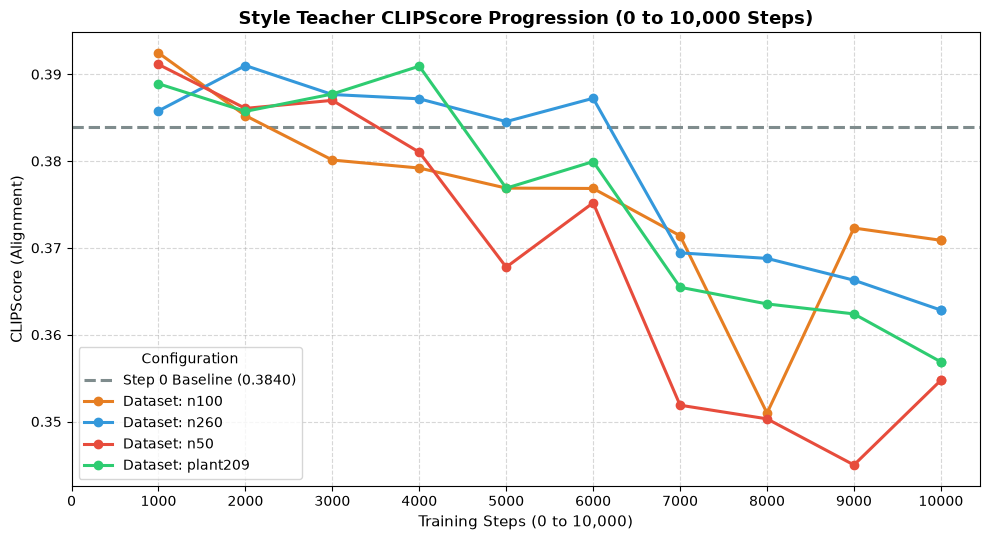

In [6]:
metrics_csv = REPO_ROOT / "outputs" / "experiment_10k" / "metrics_10k.csv"

if metrics_csv.is_file():
    df_10k = pd.read_csv(metrics_csv)
    print("[*] 10k Checkpoint Evaluation Table:")
    display(df_10k.sort_values(["dataset", "step"]))
    
    # Plot Step 0 Baseline vs 10k Progression Curves
    plt.figure(figsize=(10, 5.5))
    colors = {"baseline": "#7f8c8d", "n50": "#e74c3c", "n100": "#e67e22", "plant209": "#2ecc71", "n260": "#3498db"}
    
    base_df = df_10k[df_10k["dataset"] == "baseline"]
    base_score = base_df["clip_score"].values[0] if not base_df.empty else None
    
    if base_score is not None:
        plt.axhline(y=base_score, color=colors["baseline"], linestyle="--", linewidth=2.2, label=f"Step 0 Baseline ({base_score:.4f})")
        
    for dataset_name, group in df_10k.groupby("dataset"):
        if dataset_name == "baseline":
            continue
        grp = group.sort_values("step")
        plt.plot(grp["step"], grp["clip_score"], marker="o", linewidth=2.2, color=colors.get(dataset_name, "purple"), label=f"Dataset: {dataset_name}")
        
    plt.title("Style Teacher CLIPScore Progression (0 to 10,000 Steps)", fontsize=13, fontweight="bold")
    plt.xlabel("Training Steps (0 to 10,000)", fontsize=11)
    plt.ylabel("CLIPScore (Alignment)", fontsize=11)
    plt.xticks(range(0, 11000, 1000))
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(title="Configuration", fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print(f"[!] {metrics_csv} not found.")


## 6. 🖼️ Stage 1.7: Visual Progression Gallery (Step 0 Baseline to Step 10,000)
Visual comparison showing how ink-wash brush strokes, negative space (留白), and atmospheric mist emerge over training steps.


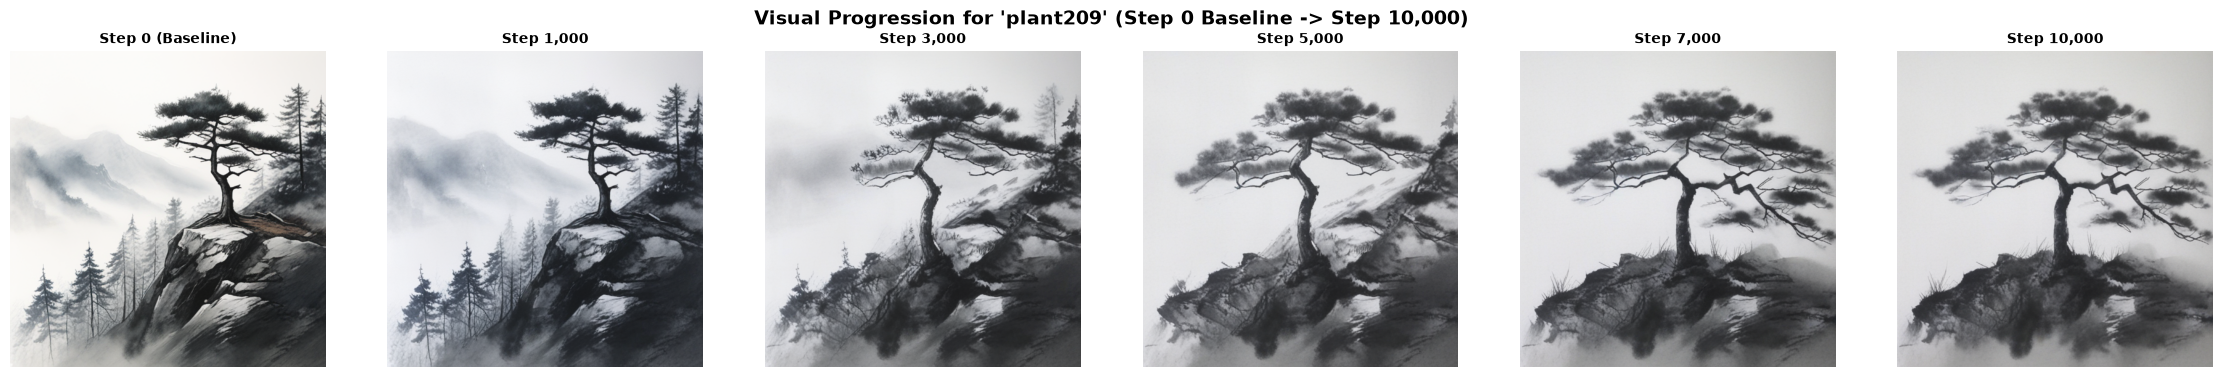

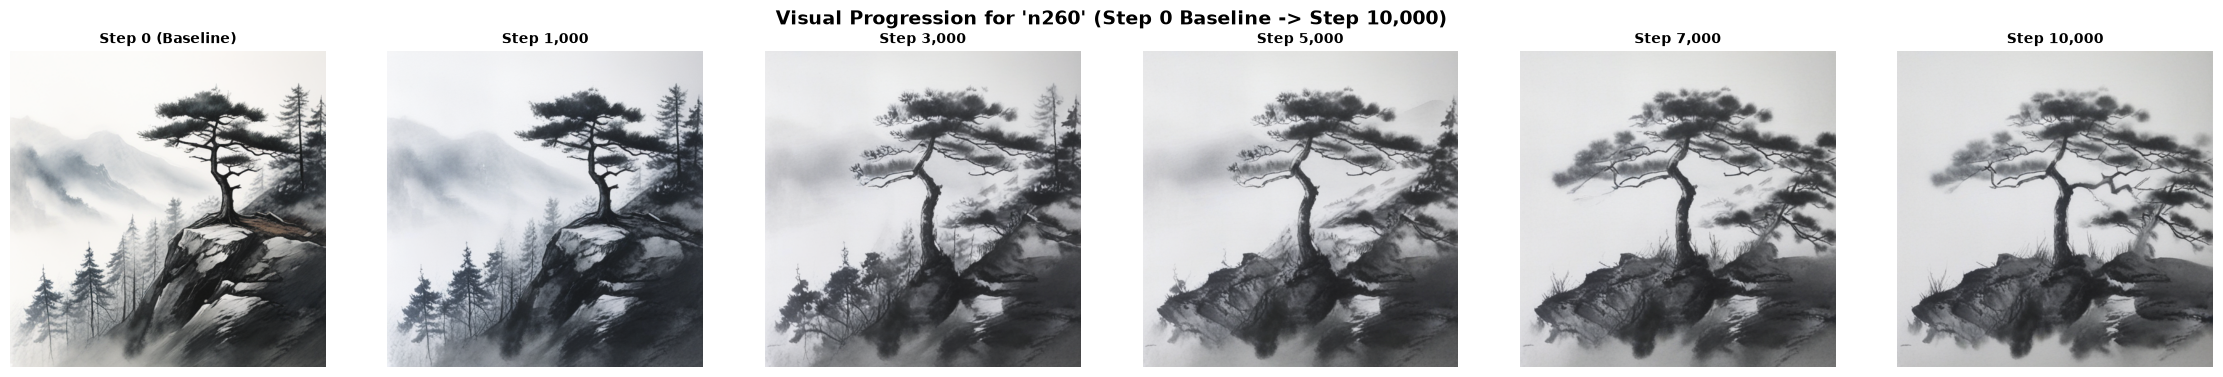

In [7]:
def render_teacher_visual_progression(dataset_name: str = "plant209", steps=[0, 1000, 3000, 5000, 7000, 10000]):
    exp_dir = REPO_ROOT / "outputs" / "experiment_10k"
    fig, axes = plt.subplots(1, len(steps), figsize=(3.8 * len(steps), 3.8))
    fig.suptitle(f"Visual Progression for '{dataset_name}' (Step 0 Baseline -> Step 10,000)", fontsize=14, fontweight="bold")
    
    found_any = False
    for idx, step in enumerate(steps):
        if step == 0:
            img_path = exp_dir / "eval_generations" / "baseline" / "step_0.png"
        else:
            img_path = exp_dir / "eval_generations" / dataset_name / f"step_{step}.png"
            
        if img_path.is_file():
            found_any = True
            img = Image.open(img_path)
            axes[idx].imshow(img)
            title_str = "Step 0 (Baseline)" if step == 0 else f"Step {step:,}"
            axes[idx].set_title(title_str, fontsize=10, fontweight="bold")
            axes[idx].axis("off")
        else:
            axes[idx].text(0.5, 0.5, f"Step {step:,}\n(Pending)", ha="center", va="center", fontsize=10)
            axes[idx].axis("off")
            
    plt.tight_layout()
    if found_any:
        plt.show()
    else:
        plt.close()
        print(f"[*] Visual progression images not yet rendered in {exp_dir / 'eval_generations'}.")

render_teacher_visual_progression("plant209")
render_teacher_visual_progression("n260")
